# 02 · Exploratory Data Analysis (EDA)

## 1. Objective
Understand the cleaned data: missingness, class balance, how features differ between CKD and non-CKD patients, correlations and outliers. Every plot answers a specific question.

> ⚠️ *Educational demonstration - not for medical diagnosis or clinical decisions.*

**Note on leakage:** EDA here is purely descriptive (no fitted transformations, no modelling choices tuned on it). All *learned* preprocessing happens later, inside pipelines fit on the training split only.

## 2. Imports

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(name): plt.savefig(FIG / name, bbox_inches="tight", dpi=150)

## 3. Dataset loading (cleaned)
We reuse the tested cleaning function from `src/` so the notebook and the training code can never drift apart.

In [2]:
from src.data_preprocessing import load_and_clean, missing_report
from src.feature_engineering import NUMERIC_FEATURES, CATEGORICAL_FEATURES, FEATURE_LABELS
df, log = load_and_clean(save=False)
df["Class"] = df["target"].map({1: "CKD", 0: "Not CKD"})
PAL = {"CKD": "#d62728", "Not CKD": "#1f77b4"}
print(df.shape)

(400, 26)


## 4. Missing-value analysis
**Why it matters:** models cannot use NaN directly, and *how* values are missing can carry information. We report count, percentage and dtype, then plot.

,Feature,Missing Count,Missing Percentage,Data Type
0,rbc,152,38.00,object
1,rc,131,32.75,float64
2,wc,106,26.50,float64
3,pot,88,22.00,float64
4,sod,87,21.75,float64
5,pcv,71,17.75,float64
6,pc,65,16.25,object
7,hemo,52,13.00,float64
8,su,49,12.25,float64
9,sg,47,11.75,float64


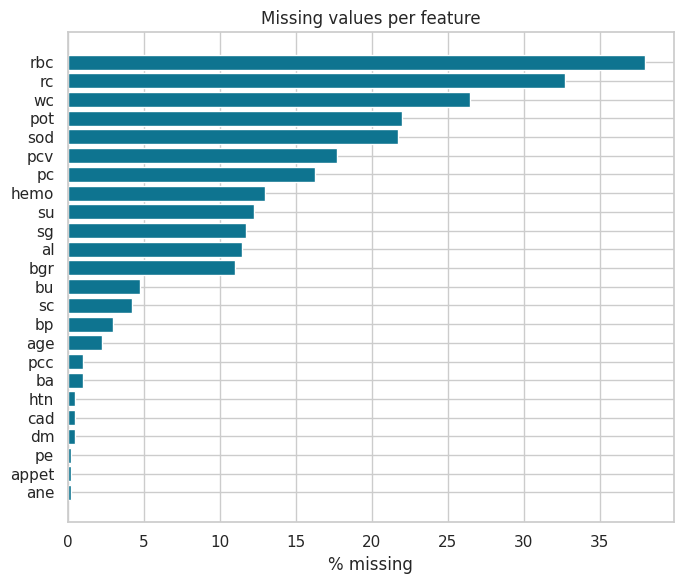

In [3]:
rep = missing_report(df.drop(columns=["Class", "target"]))
display(rep)
fig, ax = plt.subplots(figsize=(7, 6))
r = rep.sort_values("Missing Percentage")
ax.barh(r["Feature"], r["Missing Percentage"], color="#0e7490")
ax.set(xlabel="% missing", title="Missing values per feature"); plt.tight_layout(); savefig("missing_values.png"); plt.show()

In [4]:
feat = df.drop(columns=["Class", "target"])
per_row = feat.isna().sum(axis=1)
print("Missing features per patient, by class:")
display(per_row.groupby(df["Class"]).describe().round(2))
print("Patients with NO missing values:", (per_row == 0).groupby(df["Class"]).sum().to_dict())

Missing features per patient, by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
CKD,250.0,3.63,3.05,0.0,1.0,3.0,5.0,11.0
Not CKD,150.0,0.69,1.40,0.0,0.0,0.0,0.0,6.0


Patients with NO missing values: {'CKD': 43, 'Not CKD': 115}


**Interpretation.** Non-CKD patients have far fewer missing values per row than CKD patients. So in *this* dataset, "how many tests were recorded" is itself associated with the label. That is a data-collection artifact, not biology, and models can pick it up indirectly (e.g. via imputed values). We will keep it in mind for the limitations section.

**Why median (not mean) imputation?** Clinical values such as urea and creatinine are right-skewed with extreme values; the mean is dragged by those extremes while the median is not. (Shown numerically in notebook 03.)

## 5. Target distribution

,count,percent
Class,,
CKD,250,62.5
Not CKD,150,37.5


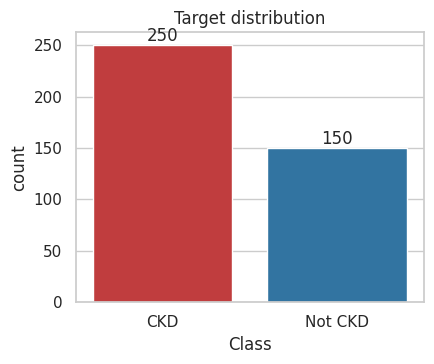

In [5]:
counts = df["Class"].value_counts(); pct = (df["Class"].value_counts(normalize=True) * 100).round(1)
display(pd.DataFrame({"count": counts, "percent": pct}))
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.countplot(data=df, x="Class", order=["CKD", "Not CKD"], palette=PAL, hue="Class", legend=False, ax=ax)
for p in ax.patches: ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set(title="Target distribution"); plt.tight_layout(); savefig("target_distribution.png"); plt.show()

The classes are moderately imbalanced (CKD is the majority). This is why we use **stratified** splitting/CV and look beyond accuracy.

## 6. Numerical features

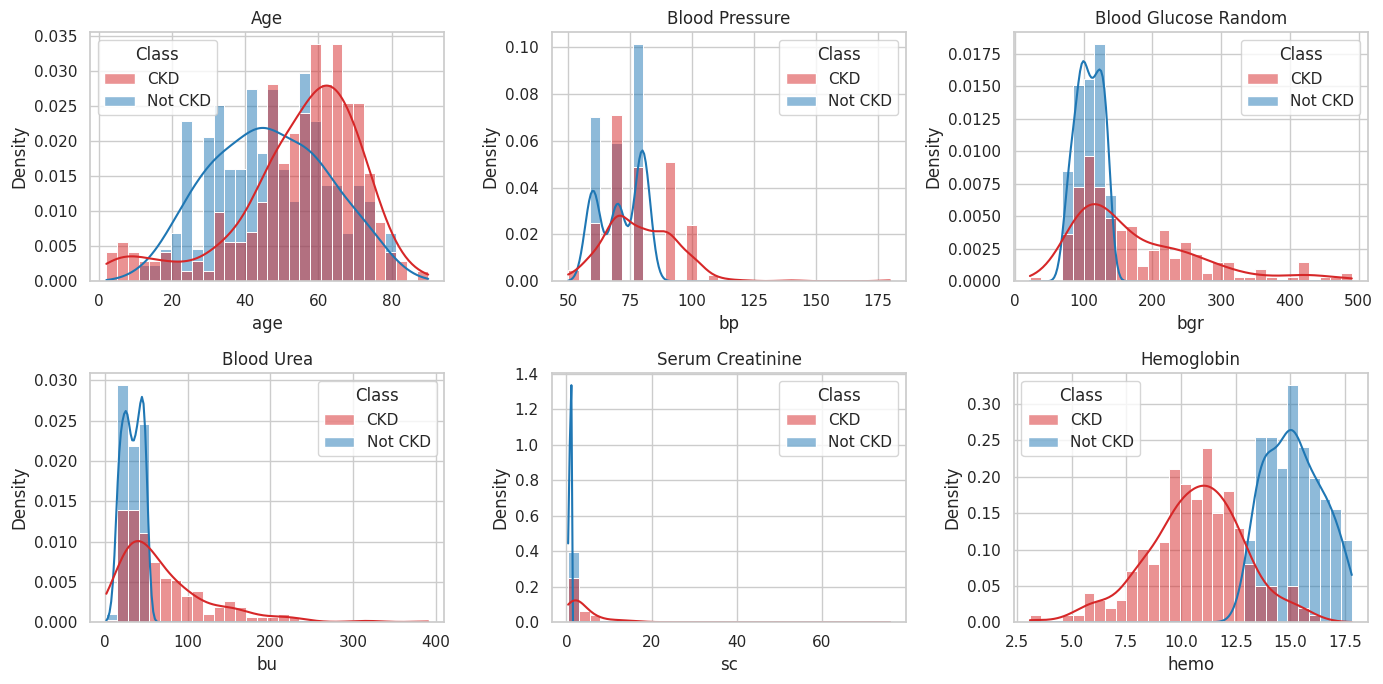

In [6]:
key = ["age", "bp", "bgr", "bu", "sc", "hemo"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), key):
    sns.histplot(data=df, x=c, hue="Class", palette=PAL, kde=True, stat="density", common_norm=False, bins=30, ax=ax)
    ax.set_title(FEATURE_LABELS[c])
plt.tight_layout(); savefig("numeric_distributions.png"); plt.show()

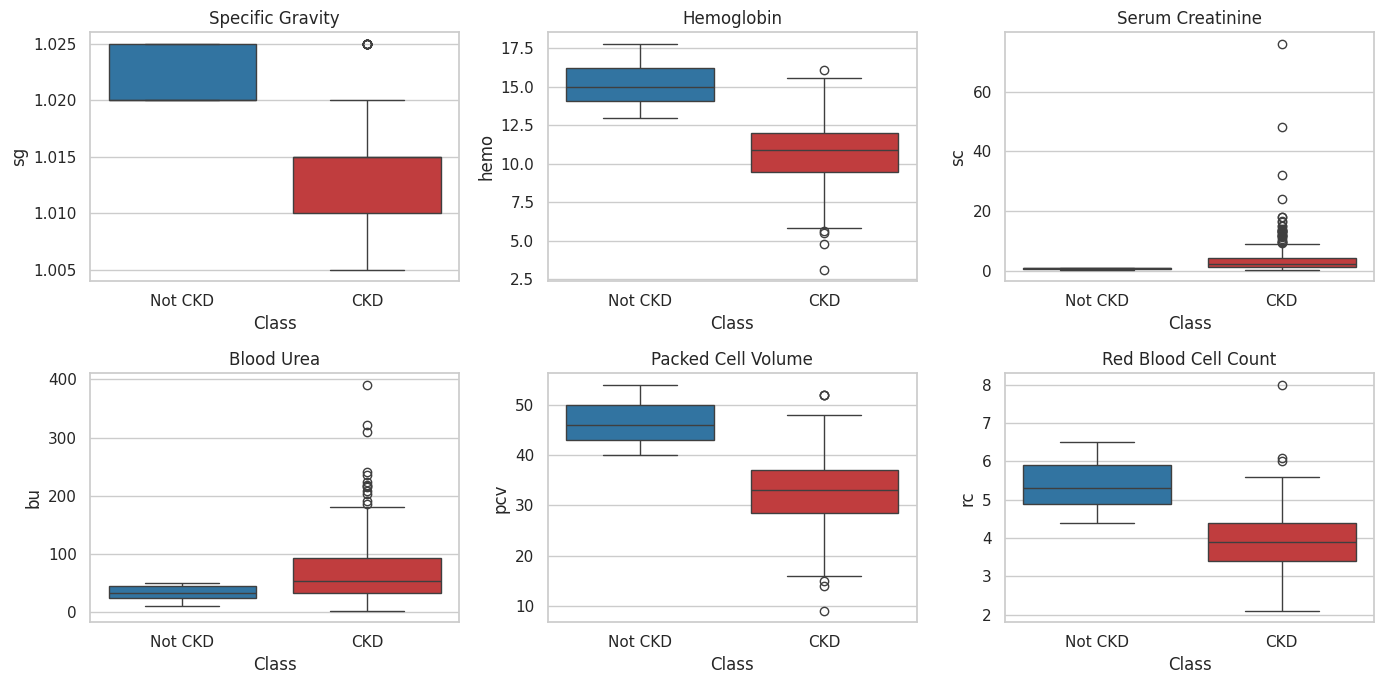

Class,CKD,Not CKD
age,59.00,46.00
bp,80.00,70.00
sg,1.01,1.02
al,2.00,0.00
su,0.00,0.00
bgr,143.50,107.50
bu,53.00,33.00
sc,2.25,0.90
sod,136.00,141.00
pot,4.30,4.50


In [7]:
key2 = ["sg", "hemo", "sc", "bu", "pcv", "rc"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), key2):
    sns.boxplot(data=df, x="Class", y=c, order=["Not CKD", "CKD"], palette=PAL, hue="Class", legend=False, ax=ax)
    ax.set_title(FEATURE_LABELS[c])
plt.tight_layout(); savefig("numeric_by_class_boxplots.png"); plt.show()
display(df.groupby("Class")[NUMERIC_FEATURES].median().T.round(2))

**Interpretation.** Hemoglobin, packed cell volume, red-cell count and specific gravity tend to be *lower* in CKD; serum creatinine, urea and glucose tend to be *higher* with a long right tail. Age overlaps heavily between classes. These are associations in this sample only.

## 7. Categorical features vs target

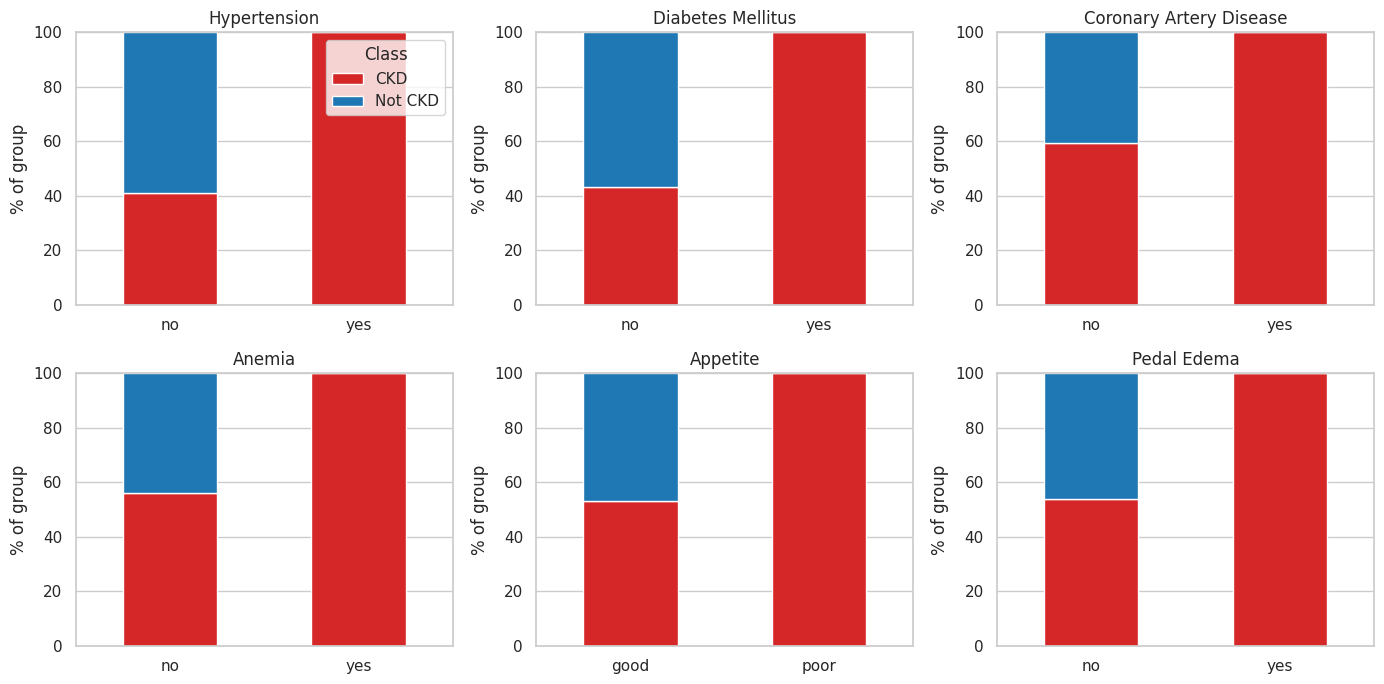

Class,CKD,Not CKD
htn,,
no,103,148
yes,147,0
NaN,0,2


Class,CKD,Not CKD
dm,,
no,113,148
yes,137,0
NaN,0,2


Class,CKD,Not CKD
cad,,
no,216,148
yes,34,0
NaN,0,2


Class,CKD,Not CKD
ane,,
no,190,149
yes,60,0
NaN,0,1


Class,CKD,Not CKD
appet,,
good,168,149
poor,82,0
NaN,0,1


Class,CKD,Not CKD
pe,,
no,174,149
yes,76,0
NaN,0,1


In [8]:
cats = ["htn", "dm", "cad", "ane", "appet", "pe"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), cats):
    ct = pd.crosstab(df[c], df["Class"], normalize="index")[["CKD", "Not CKD"]] * 100
    ct.plot(kind="bar", stacked=True, color=[PAL["CKD"], PAL["Not CKD"]], ax=ax, legend=(c == "htn"))
    ax.set(title=FEATURE_LABELS[c], xlabel="", ylabel="% of group"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); savefig("categorical_vs_target.png"); plt.show()
for c in cats: display(pd.crosstab(df[c], df["Class"], dropna=False))

Patients with hypertension, diabetes, anemia, poor appetite or pedal edema are almost all CKD *in this sample*. Note this reflects who is in the dataset, not the general population.

## 8. Correlation analysis
Pearson correlation measures *linear* association from -1 to +1. **Positive**: both rise together. **Negative**: one rises as the other falls. Roughly |r|<0.3 weak, 0.3-0.7 moderate, >0.7 strong. **Correlation is not causation.**

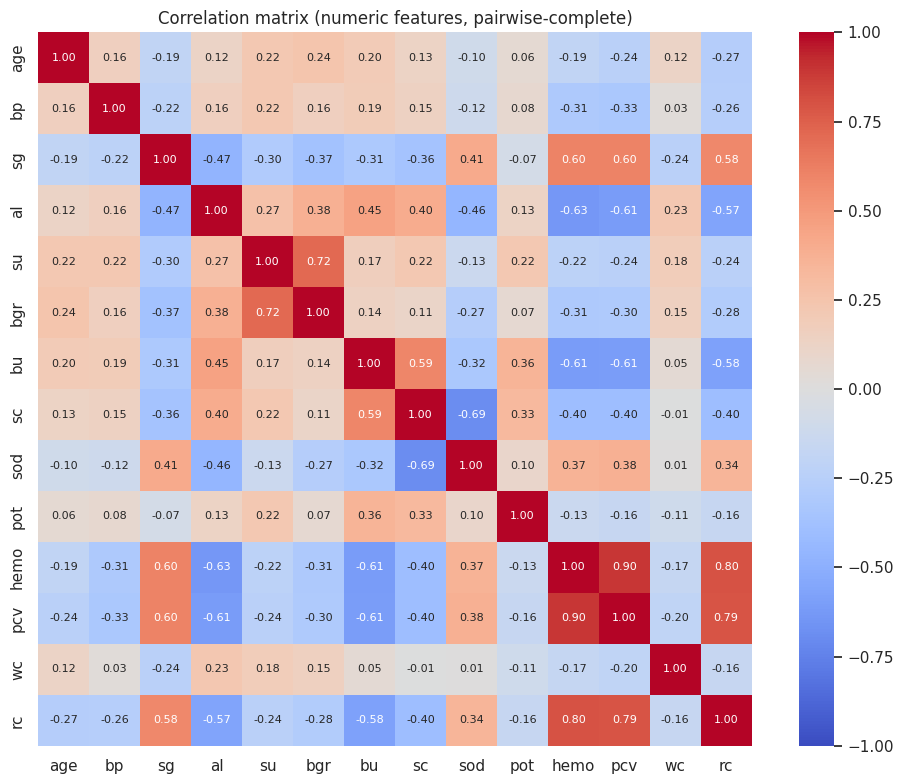

Correlation with target (1 = CKD):


,r
hemo,-0.769
pcv,-0.741
sg,-0.732
rc,-0.699
sod,-0.376
pot,0.085
age,0.227
wc,0.232
bp,0.294
sc,0.300


In [9]:
corr = df[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation matrix (numeric features, pairwise-complete)"); plt.tight_layout(); savefig("correlation_matrix.png"); plt.show()
print("Correlation with target (1 = CKD):")
display(df[NUMERIC_FEATURES + ["target"]].corr()["target"].drop("target").sort_values().round(3).to_frame("r"))

**Interpretation.** The strongest pairs printed below show which features carry overlapping information (e.g. red-cell measures such as hemoglobin, PCV and RBC count are physiologically linked). Overlapping features make individual Logistic Regression coefficients less stable - one reason we regularise and interpret them carefully. Correlations with the target are *associations*, not causes.

In [10]:
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().rename("r").to_frame()
pairs["abs_r"] = pairs.r.abs()
display(pairs.sort_values("abs_r", ascending=False).head(8).round(3)[["r"]])

r
hemo pcv   0.895
     rc    0.799
pcv  rc    0.792
su   bgr   0.718
sc   sod  -0.690
al   hemo -0.635
     pcv  -0.612
bu   hemo -0.610

## 9. Outlier analysis
**Do not delete outliers automatically.** In medicine, an extreme creatinine of 76 mg/dl is a real (severe) observation, not an error. We *flag* with the IQR rule (values beyond 1.5×IQR from the quartiles), then inspect with domain knowledge.

,feature,min,max,IQR_low,IQR_high,n_outliers,pct
4,su,0.000,5.000,0.00,0.00,61,17.4
7,sc,0.400,76.000,-1.95,5.65,51,13.3
6,bu,1.500,391.000,-31.50,124.50,38,10.0
1,bp,50.000,180.000,55.00,95.00,36,9.3
5,bgr,22.000,490.000,3.00,259.00,34,9.6
8,sod,4.500,163.000,124.50,152.50,16,5.1
0,age,2.000,90.000,8.25,98.25,10,2.6
12,wc,2200.000,26400.000,1550.00,14750.00,10,3.4
9,pot,2.500,47.000,2.15,6.55,4,1.3
10,hemo,3.100,17.800,3.25,22.05,1,0.3


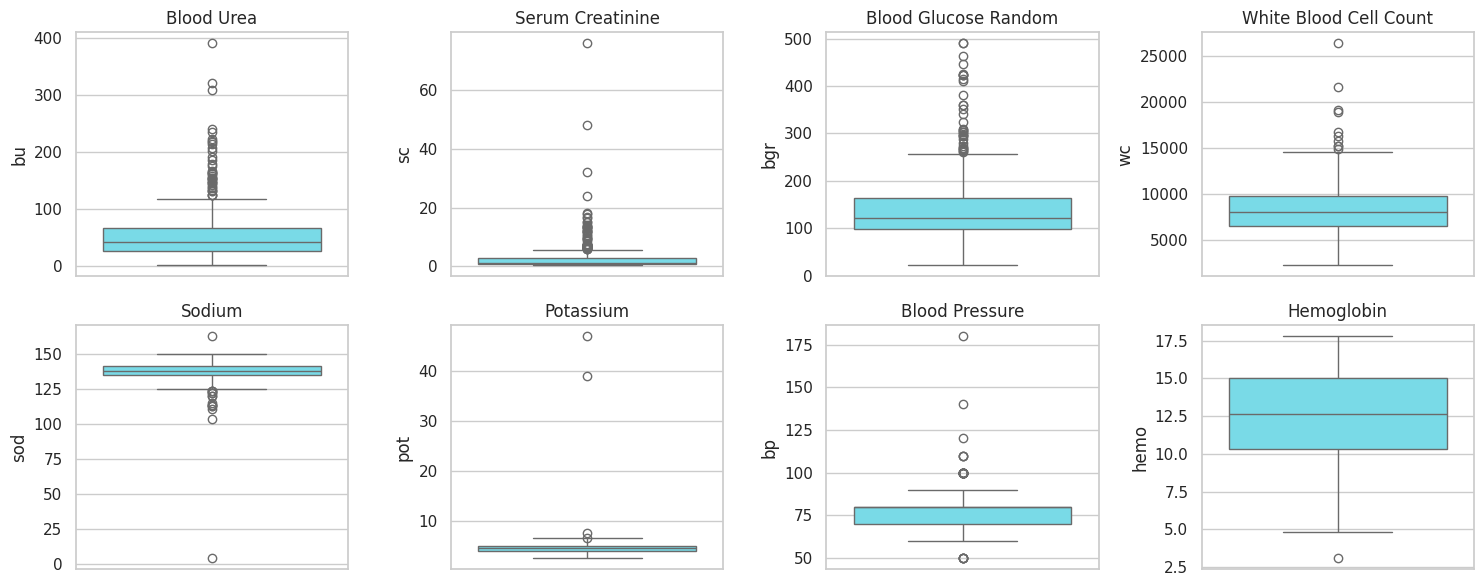

In [11]:
rows = []
for c in NUMERIC_FEATURES:
    s = df[c].dropna(); q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    rows.append({"feature": c, "min": s.min(), "max": s.max(), "IQR_low": round(lo, 2), "IQR_high": round(hi, 2),
                 "n_outliers": int(((s < lo) | (s > hi)).sum()), "pct": round(((s < lo) | (s > hi)).mean()*100, 1)})
display(pd.DataFrame(rows).sort_values("n_outliers", ascending=False))
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), ["bu", "sc", "bgr", "wc", "sod", "pot", "bp", "hemo"]):
    sns.boxplot(y=df[c], color="#67e8f9", ax=ax); ax.set_title(FEATURE_LABELS[c])
plt.tight_layout(); savefig("outlier_boxplots.png"); plt.show()

In [12]:
print("Domain-aware inspection of implausible-looking values:")
print("Sodium < 100 mEq/L :", df.loc[df.sod < 100, ["sod", "Class"]].to_dict("records"))
print("Potassium > 10 mEq/L:", df.loc[df.pot > 10, ["pot", "Class"]].to_dict("records"))
print("Creatinine > 15 mg/dl:", (df.sc > 15).sum(), "rows, classes:", df.loc[df.sc > 15, "Class"].unique())

Domain-aware inspection of implausible-looking values:
Sodium < 100 mEq/L : [{'sod': 4.5, 'Class': 'CKD'}]
Potassium > 10 mEq/L: [{'pot': 39.0, 'Class': 'CKD'}, {'pot': 47.0, 'Class': 'CKD'}]
Creatinine > 15 mg/dl: 9 rows, classes: <ArrowStringArray>
['CKD']
Length: 1, dtype: str


**Decision.** Most flagged points (high urea, creatinine, glucose) are *clinically meaningful* and concentrated in CKD - we **keep** them. A few (sodium 4.5; potassium 39 and 47) are physiologically implausible and look like data-entry errors, but with no source records to verify we also keep them and rely on **median imputation, scaling and tree-based models** (which are insensitive to extreme magnitudes). Removing them would be a judgement call better made with the data's owners; we document it instead.

## 10. Conclusions
1. Classes: CKD majority → stratify.
2. Missingness is heavy and class-dependent → keep imputation inside the pipeline; report as a limitation.
3. Hemoglobin, PCV, RBC count, specific gravity, creatinine, urea, albumin and history flags separate the classes visually.
4. Correlated feature groups exist (red-cell measures; urea/creatinine).
5. Outliers are mostly genuine; not deleted.